# LDOS DAY 4: ML for Systems Challenge Sandbox

Welcome back! So far, we've seen two models (Perceptron and KNN, maybe more if you explored yesterday), one engineered feature (`last_latency_block_io_us`), and a bunch of hyperparameter tuning. Today, we're taking off the reins and giving you a **sandbox** to use what we've learned to develop your best model, trying new models, features, and hyperparameters before our award ceremony Friday.

## Quick Recap: What We've Seen

* Day 1: We explored a synthetic dataset with EDA, learning about the importance of good data (remember, *data is the foundation of science*), data analysis (graphing, correlation), and formal testing methods (t-tests).

* Day 2: Trained our first real model (a baseline Perceptron) on real RAID 1 data from LDOS, and learned about some introuctory hyperparameter tuning, train/test splits, and data normalization.

* Day 3: Trained a second model (KNN), engineered our own new feature (history, called `last_latency_block_io_us'), and tuned K

## Note: Today's Dataset

As a reminder, you're receiving the full `rainsong_labeled` dataset today, with the knowledge that we've isolated a test split so that we can test how well your model handles unseen data. To "test" your model, you'll be using a test/verification split, allowing you to use some locally unseen data to make decisions, the same way we'd do it in real research.

# Respond Here: Double-click on this cell and add your names below.

Team Member Names:James Harper & Adrian Espinosa

Group #: 16

Team Name: AJ

# Loading Libraries

In this notebook, we’ll use:

- *polars* for working with dataframes
- *matplotlib* and *seaborn* for creating charts and graphs
- *numpy* for data normalization
- *sklearn* for our models

We'll load them in the next code cell. Click on the play button next to the cell to run just the cell below.

## Note: External Libraries

Feel free to use any other libraries you're aware of/come accross while reading documentation, with two caveats:

  1. All your models must come from sklearn, no torch or tensorflow models

  2. No automatic hyperparameter optimization frameworks (if curious, look up RayTune and Optuna)

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn

# Model and metric imports
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

# Custom method imports
from library import process_block_io_flags, time_model_execution, download_data

# Load the Full Training Dataset

Here it is: the full thing, including over 32,000,000 rows of data. The `*` wildcard tells Polars to read every file and stack them into a single DataFrame.

Using the full dataset will take a lot longer to run and train than a single parquet file. For quick iterative development, you may want to start with a single file.

In [4]:
# Full dataset
#df_read = pl.read_parquet("rainsong_labeled/*.parquet")
download_data()

# Single file, uncomment and re-run this cell if you want more rapid development
df_read = pl.read_parquet("rainsong_labeled/1.parquet")

print("Total columns: ", df_read.columns)
print("Total rows: ", df_read.shape[0])

Download complete.
Unzipping rainsong_data.zip...
Unzipping complete.
Total columns:  ['cpu', 'device', 'sector', 'segments', 'block_io_bytes', 'ts_uptime_us', 'block_io_flags', 'queue_length_segment_ios', 'queue_length_4k_ios', 'collection_id', 'finish_ts_uptime_us', 'block_latency_us', 'block_io_latency_us', 'measured_latency_us', 'block_io_flags_string', 'label85', 'label90', 'label95']
Total rows:  325294


# Respond Here: A Larger Dataset

  1. How many rows do we have now, compared to the single file we worked with on Days 2 and 3?
325294, this is like 5x more data, thats actually just one parquet, nevermind, but I'm not going to load that much data now, its basically 120 * that
  2. Does anything about your workflow need to change now that we're working with this much data (think about cell runtime, how often you re-run the whole pipeline)?

  Yeah we defintely need to be more conservative with how often we train, becuase it will take longer

# (Optional) Bring Back History

Found that `last_latency_block_io_us` was useful? Feel free to rebuild it here using the full dataset

In [5]:
import warnings

# Only finished I/Os have a real latency we can "look back" at
df_finished = df_read.filter(
    pl.col("finish_ts_uptime_us").is_not_null()
).select([
    "device",
    pl.col("ts_uptime_us") + 1,
    pl.col("block_io_latency_us").alias("last_latency_block_io_us") ,
])

# Sort our dataframe by ts_uptime_us
# COMMENT THESE OUT FOR FULL DAT SET
df_read_sorted = df_read
df_finished_sorted = df_finished

# For each row, find the most recently finished read on the same device
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    df_with_history = df_read_sorted.join_asof(
        df_finished_sorted,
        on="ts_uptime_us",
        by="device",
        strategy="backward",
    )

# Display our new feature
display(df_with_history.select(
    ["device", "ts_uptime_us", "last_latency_block_io_us"]
).head())

device,ts_uptime_us,last_latency_block_io_us
i64,i64,i64
271581186,406416557135,null
271581185,406416557190,null
271581186,406416557219,8534
271581184,406416557247,null
271581185,406416557269,8498


# Rebuilding our Feature Pipeline

Same processing we did on Day 2 and 3, dropping **leakage** columns, quantizing `block_io_flags_string`, and filtering down to only read operations.

In [6]:
# Drop columns that represent future information or unused target labels
# Note: Replace with df_with_history if using the history feature
df_drop = df_with_history.drop([
    'collection_id', 'block_io_latency_us', 'block_latency_us',
    'measured_latency_us', 'label85', 'label95', 'finish_ts_uptime_us'
])

# Separate flags into discrete columns
df = process_block_io_flags(df_drop)

# Only keep 'Read' operations — remember, we can only make predictions on reads
#This is where we are droppping more columns
df_reads = df.filter(pl.col('Read'))
df_reads = df_reads.drop('Idle')
df_reads = df_reads.drop('NoMerge')
df_reads = df_reads.drop('queue_length_segment_ios')
df_reads = df_reads.drop('Read')
df_reads = df_reads.drop('Write')
df_reads = df_reads.drop('segments')

# Handle the the "no previous read yet" rows with median latency
# Note: Uncomment this if using history
median_latency = df_reads["last_latency_block_io_us"].median()
df_reads = df_reads.with_columns(
        pl.col("last_latency_block_io_us").fill_null(median_latency)
 )

print("Number of read operations:", df_reads.shape[0])
display(df_reads.head())
#display(df_reads.filter(pl.col('Idle')))

Number of read operations: 79087


cpu,device,sector,block_io_bytes,ts_uptime_us,block_io_flags,queue_length_4k_ios,label90,last_latency_block_io_us,Sync
i64,i64,i64,i64,i64,i64,i64,bool,f64,bool
19,271581186,13891760,141824,406416557436,2048,83,false,8460.0,true
22,271581186,1099686032,168448,406416557529,2048,125,false,8604.0,true
6,271581185,273022744,33280,406416557963,2048,92,false,7813.0,true
3,271581185,581767008,18432,406416558057,2048,102,false,7887.0,true
20,271581185,845959504,38912,406416558096,2048,112,false,7775.0,true


# Respond Here: Feature Engineering

1. Is there a feature you haven't tried yet that today's lesson made you curious about (Hint: a feature that would help a class of models specifically)?

I'm going to be honest, I can't think of anything, we tried to look around for correlations, but I don't know if we found anything. One hypothesis I had was that we could implement some sort of shortcut, where processes with the same cpu id would have the same classificaiton, but I don't know if that would work out, or how we could implement it into the model while consdering other factors

# Train/Validation Split

This is identical in use to the train/test split we've been doing, however, remember that we now have an external test set. Feel free to use the validation set freely for tuning decisions, cross-validation, or anything else!

In [7]:
# Add a row index column to the DataFrame
df_reads_indexed = df_reads.with_row_index()

# Split the data into training and validation sets (80-20 split)
train_df = df_reads_indexed.sample(fraction=0.8, with_replacement=False, seed=42)
val_df = df_reads_indexed.join(train_df.select('index'), on='index', how='anti')

# Drop the index column from the split dataframes
train_df = train_df.drop('index')
val_df = val_df.drop('index')

# Confirm our split
print("Training data shape:", train_df.shape)
print("Validation data shape:", val_df.shape)

Training data shape: (63269, 10)
Validation data shape: (15818, 10)


In [8]:
# Separate features and target
train_target_np = train_df['label90'].to_numpy()
val_target_np = val_df['label90'].to_numpy()

train_features = train_df.drop('label90')
val_features = val_df.drop('label90')

train_features_np = train_features.to_numpy()
val_features_np = val_features.to_numpy()

# Normalize our data (helps distance-based and margin-based models especially)
norm_np = np.abs(train_features_np).max(axis=0) + 0.0001
train_features_np = train_features_np / norm_np
val_features_np = val_features_np / norm_np

print("Feature columns:", train_features.columns)

Feature columns: ['cpu', 'device', 'sector', 'block_io_bytes', 'ts_uptime_us', 'block_io_flags', 'queue_length_4k_ios', 'last_latency_block_io_us', 'Sync']


# Respond Here: Two Splits

  1. Why does it matter that you're tuning against `val_df` and not the `test_df` we'll be using to grade your model?

  It matters because of data leakage, we would effectively be giving the model the answer key.

  2. If your team picks a final model based on validation performance alone, and your test performance doesn't quite reach the same metrics, does that mean something went wrong? Why or why not?

  It does. It means we overfit to the validation data, and then when we extrapolate to the testing data, we get innacuracies

# Evaluation Function

Y'all have seen this before, shoutout *code refactoring*.

In [9]:
# Calculate accuracy and speed evaluation metrics
def evaluate_model(name, model, features_np, target_np):
    predictions = model.predict(features_np)

    accuracy = accuracy_score(target_np, predictions)
    precision = precision_score(target_np, predictions)
    recall = recall_score(target_np, predictions)
    f1 = f1_score(target_np, predictions)
    conf_matrix = confusion_matrix(target_np, predictions)
    ts_ns = time_model_execution(model, features_np)

    print()
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Time per prediction: {ts_ns:.2f}ns, {ts_ns/1000:.2f}us")
    print("Confusion Matrix:")
    print(conf_matrix)
    print()

    return {"name": name, "accuracy": accuracy, "f1": f1, "time_ns": ts_ns}

# We'll collect every model's results here for a final comparison
results = []

# (Optional) Bring your Best Models Forward

Feel free to retrain your strongest models from Days 2 and 3 here, on the full dataset, so you can have an up-to-date baseline before further experimentation.

As a reminder, training on larger datasets takes a lot more time, reflect on how your workflow may need to shift with respect to this.

In [10]:
# Retrain your best Perceptron with the hyperparameters that worked well previously
baseline_percept = MLPClassifier(hidden_layer_sizes=(9,8), activation='relu', solver='adam', max_iter=500, random_state=42)
baseline_percept.fit(train_features_np, train_target_np)
results.append(evaluate_model("Perceptron", baseline_percept, val_features_np, val_target_np))

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...

--- Perceptron ---
Accuracy:  0.8621
Precision: 0.8572
Recall:    0.9887
F1 Score:  0.9183
Time per prediction: 128.57ns, 0.13us
Confusion Matrix:
[[ 1382  2041]
 [  140 12255]]



In [11]:
# Retrain your best KNN with the hyperparameters and distance metric that worked well previously
baseline_knn = KNeighborsClassifier(n_neighbors=9)
baseline_knn.fit(train_features_np, train_target_np)
results.append(evaluate_model("KNN", baseline_knn, val_features_np, val_target_np))

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...

--- KNN ---
Accuracy:  0.8506
Precision: 0.8504
Recall:    0.9822
F1 Score:  0.9115
Time per prediction: 44923.78ns, 44.92us
Confusion Matrix:
[[ 1281  2142]
 [  221 12174]]



# New Models

Today's lesson introduced you to four new model types. You absolutely don't have to try all of them, especially given training times with a larger dataset, these are just some minimal starting points you can experiment with.

# Logistic Regression

In [12]:
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(train_features_np, train_target_np)
results.append(evaluate_model("Logistic Regression", log_reg, val_features_np, val_target_np))

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...

--- Logistic Regression ---
Accuracy:  0.8568
Precision: 0.8526
Recall:    0.9881
F1 Score:  0.9154
Time per prediction: 23.18ns, 0.02us
Confusion Matrix:
[[ 1306  2117]
 [  148 12247]]



# Decision Tree

*Hint: Try tuning `max_depth`, maybe EDA would help?*

In [13]:
tree_model = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_model.fit(train_features_np, train_target_np)
results.append(evaluate_model("Decision Tree", tree_model, val_features_np, val_target_np))

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...

--- Decision Tree ---
Accuracy:  0.8605
Precision: 0.8587
Recall:    0.9838
F1 Score:  0.9170
Time per prediction: 88.61ns, 0.09us
Confusion Matrix:
[[ 1417  2006]
 [  201 12194]]



# Random Forest

*Hint: Keep an eye on your timing output*

In [14]:
forest_model = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
forest_model.fit(train_features_np, train_target_np)
results.append(evaluate_model("Random Forest With  Data Set", forest_model, val_features_np, val_target_np))

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...

--- Random Forest With  Data Set ---
Accuracy:  0.8637
Precision: 0.8579
Recall:    0.9901
F1 Score:  0.9193
Time per prediction: 1839.57ns, 1.84us
Confusion Matrix:
[[ 1390  2033]
 [  123 12272]]



# Support Vector Machine (SVM)

*Hint: SVMs can be slow to train, maybe try fitting on a smaller sample of `train_features_np`*

In [15]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(train_features_np, train_target_np)
results.append(evaluate_model("SVM", svm_model, val_features_np, val_target_np))

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...

--- SVM ---
Accuracy:  0.8561
Precision: 0.8522
Recall:    0.9875
F1 Score:  0.9149
Time per prediction: 717771.85ns, 717.77us
Confusion Matrix:
[[ 1301  2122]
 [  155 12240]]



# Respond Here: Decisions, Decisions...

  1. Of the models you've tested above, which seem like they might be worth keeping for further testing, and which don't? Why do you think this is?

  The other day I ran a bunch of perceptrons overnight, and (9,8) had the best accuracy, we put it in here and it is insane, but we may want to do K-fold-Cross validation to make sure its not overfitting

  Woah, all that and decision tree is even faster, but it may overfit, we might have to tune the depth

  Random Forest is even better, but it takes longer to train, decision tree is super quick so it might have a balance of both

  The SVM just took 3 min to run to only give us an F1 of 0.9704, so we will likely not use that

  Okay that history change totally downgraded our accuracy from 0.9975 to 0.9193, I'm going to switch to HistGradientBoostingClassifier, which was the best from my prior testing

# Overfitting

Today, we learned that a model that does great on training data but not so much on validation data is a red flag. Pick the best model you have so far and compare its training performance to its validation performance.

In [16]:
# Swap in whichever model you're currently considering
candidate_model = forest_model

train_predictions = candidate_model.predict(train_features_np)
train_accuracy = accuracy_score(train_target_np, train_predictions)

val_accuracy = accuracy_score(val_target_np, candidate_model.predict(val_features_np))

print(f"Training accuracy:   {train_accuracy:.6f}")
print(f"Validation accuracy: {val_accuracy:.6f}")
print(f"Gap: {train_accuracy - val_accuracy:.6f}")

Training accuracy:   0.866680
Validation accuracy: 0.863700
Gap: 0.002981


# Respond Here: The Train/Validation Gap

  1. How big is the gap between your training and validation accuracy? Does it look like its underfitting, overfitting, or a good balance?

  Gap: 0.000332, I think we are good, I might implement K-fold cross over in a bit. Nevermind sklearn K-fold cross validation built in.

  2. Whats one thing you could try to close the gap (*Hint: Look up K-Fold Cross-Validation or L1/L2 Regularization if you're overfitting).

  Defintely the cross fold validation

# (Optional) Revisiting EDA for Feature Selection

With the full dataset and (maybe) some new features, its worth it to re-run this check from Day 3 to check correlations

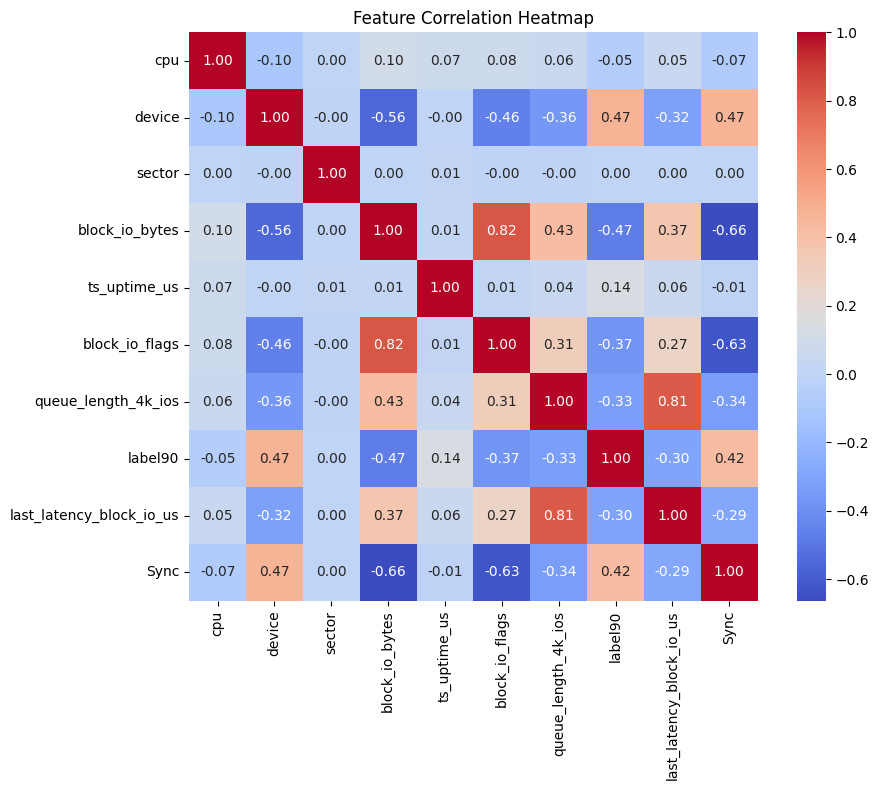

In [18]:
# Correlation matrix/heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df_reads.to_pandas().corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Sandbox, Your ML for Systems Challenge Submission

Sweet, sweet freedom. This is a space for you to explore new models, features, hyperparameters, or whatever else you want! The model in the cell below will be what we test for our ML for Systems Challenge, so make sure to comment out everything you don't want submitted (including from earlier rows).

In [19]:
# Good Luck!

model = HistGradientBoostingClassifier(l2_regularization=0.01, learning_rate=0.03,max_depth=8, max_iter=1000, random_state=42)


model.fit(train_features_np, train_target_np)
results.append(evaluate_model("Gradient", model, val_features_np, val_target_np))

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...

--- Gradient ---
Accuracy:  0.8650
Precision: 0.8615
Recall:    0.9863
F1 Score:  0.9197
Time per prediction: 14997.84ns, 15.00us
Confusion Matrix:
[[ 1457  1966]
 [  170 12225]]



# Looking Back

Thought I'd give y'all some code to help view your results better, use as you see fit!

In [20]:
print(f"{'Model':<28}{'Accuracy':<12}{'F1':<12}{'Speed (us)':<12}")
for r in sorted(results, key=lambda r: r['f1'], reverse=True):
    print(f"{r['name']:<28}{r['accuracy']:<12.4f}{r['f1']:<12.4f}{r['time_ns']/1000:<12.2f}")

Model                       Accuracy    F1          Speed (us)  
Gradient                    0.8650      0.9197      15.00       
Random Forest With  Data Set0.8637      0.9193      1.84        
Perceptron                  0.8621      0.9183      0.13        
Decision Tree               0.8605      0.9170      0.09        
Logistic Regression         0.8568      0.9154      0.02        
SVM                         0.8561      0.9149      717.77      
KNN                         0.8506      0.9115      44.92       


# Respond Here: End-of-Week Check-In

1. Based on everything above, which model did your team end up choosing? What did you change from the defaults to boost performance? Why? (3-4 Sentences)

2. Based on your results above, do you feel like you're optimizing more for the Feature Forensics Award or the Goldilocks Award?

3. If given more time, whats something you'd want to try next?

4. What was your favorite lesson or thing you learned this week?

5. What was your least favorite, or a space you feel like could've been improved?

## Download and Turn in this notebook

### Note: Make Sure You're Naming the Notebook Correctly!

Make sure you've run all the code cells and answered every "Respond Here" cell, then, download this notebook as "Group_[group number]_Module_4.ipynb" and submit at this link: https://forms.gle/Rg66ifU12xapnzRj6